# Tasks 3.5 & 3.6 — SP vs μP Comparison & Scaling Law Extrapolation

**Task 3.5** — Overlay the Standard Parameterization (SP) and μP scaling curves on the same
log-log plot, fit power laws to both, show LR sweep side-by-side, and answer the analysis questions:
- Does μP improve validation loss, especially at larger scales?
- Does μP yield a steeper (better) scaling exponent?
- Why does a fixed LR degrade under SP at larger widths? How does μP address this?

**Task 3.6** — Using the better-fitting curve (SP, R²=0.956), predict the validation loss for a
model with **~880M parameters** (10× XL) and compute a 1σ confidence interval via the delta method.

Run this after Tasks 2.3 (all SP models trained) and 3.4 (all μP models trained).

In [1]:
import os
if not os.path.exists("configs"):
    os.chdir("..")
print("Working directory:", os.getcwd())

Working directory: /Users/shubhamtanwar/Desktop/ML-Final-Project


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def power_law(N, a, alpha, c):
    return a * N**(-alpha) + c

def fit_power_law(params, losses):
    p0 = [1.0, 0.1, max(0.01, losses.min() * 0.5)]
    try:
        popt, pcov = curve_fit(
            power_law, params, losses, p0=p0,
            bounds=([0, 0, 0], [np.inf, 2.0, np.inf]), maxfev=30000
        )
    except RuntimeError:
        popt, pcov = curve_fit(power_law, params, losses, p0=p0, maxfev=80000)
    return popt, pcov

## Load SP and μP Results

In [3]:
sp_path  = 'outputs/results/scaling_results.json'
mup_path = 'outputs/results/mup_scaling_results.json'

assert os.path.exists(sp_path),  f'{sp_path} not found — run Task 2.3 first.'
assert os.path.exists(mup_path), f'{mup_path} not found — run Task 3.4 first.'

with open(sp_path)  as f: sp_data  = json.load(f)
with open(mup_path) as f: mup_data = json.load(f)

sp_data.sort( key=lambda r: r['param_count'])
mup_data.sort(key=lambda r: r['param_count'])

sp_params  = np.array([r['param_count'] for r in sp_data],  dtype=float)
sp_losses  = np.array([r['val_loss']    for r in sp_data],  dtype=float)
mup_params = np.array([r['param_count'] for r in mup_data], dtype=float)
mup_losses = np.array([r['val_loss']    for r in mup_data], dtype=float)

print(f"{'Model':<14} {'Params':>12} {'SP Loss':>10} {'μP Loss':>10} {'Δ (μP−SP)':>12}")
print('-' * 62)
for sp_r, mup_r in zip(sp_data, mup_data):
    delta = mup_r['val_loss'] - sp_r['val_loss']
    tag = '← μP better' if delta < 0 else '← SP better'
    print(f"{sp_r['name']:<14} {sp_r['param_count']:>12,} "
          f"{sp_r['val_loss']:>10.4f} {mup_r['val_loss']:>10.4f} "
          f"{delta:>+12.4f}  {tag}")

Model                Params    SP Loss    μP Loss    Δ (μP−SP)
--------------------------------------------------------------
tiny              1,049,728     1.5881     1.5018      -0.0863  ← μP better
small             3,049,920     1.4441     1.4942      +0.0501  ← SP better
medium           11,408,256     1.2108     1.2445      +0.0337  ← SP better
large            32,516,608     1.1543     1.2351      +0.0808  ← SP better
xl               86,526,720     1.1847     1.4280      +0.2434  ← SP better


## Fit Power Laws to Both Curves

In [4]:
sp_popt,  sp_pcov  = fit_power_law(sp_params,  sp_losses)
mup_popt, mup_pcov = fit_power_law(mup_params, mup_losses)

sp_perr  = np.sqrt(np.diag(sp_pcov))
mup_perr = np.sqrt(np.diag(mup_pcov))

def r_squared(losses, params, popt):
    preds = power_law(params, *popt)
    return 1 - np.sum((losses - preds)**2) / np.sum((losses - losses.mean())**2)

sp_r2  = r_squared(sp_losses,  sp_params,  sp_popt)
mup_r2 = r_squared(mup_losses, mup_params, mup_popt)

a, alpha, c          = sp_popt
a_m, alpha_m, c_m    = mup_popt

print('SP  power law:')
print(f'  L(N) = {a:.4f} · N^(-{alpha:.4f}) + {c:.4f}')
print(f'  a={a:.4f}±{sp_perr[0]:.4f}  alpha={alpha:.4f}±{sp_perr[1]:.4f}  c={c:.4f}±{sp_perr[2]:.4f}')
print(f'  R² = {sp_r2:.4f}')

print('\nμP  power law:')
print(f'  L(N) = {a_m:.4f} · N^(-{alpha_m:.4f}) + {c_m:.4f}')
print(f'  a={a_m:.4f}±{mup_perr[0]:.4f}  alpha={alpha_m:.4f}±{mup_perr[1]:.4f}  c={c_m:.4f}±{mup_perr[2]:.4f}')
print(f'  R² = {mup_r2:.4f}')

print(f'\nKaplan et al. (natural language) α ≈ 0.076')
better = 'SP' if sp_r2 >= mup_r2 else 'μP'
print(f'Better fit: {better}  (R²={max(sp_r2, mup_r2):.4f})')

SP  power law:
  L(N) = 392.1487 · N^(-0.4782) + 1.0848
  a=392.1487±1521.3530  alpha=0.4782±0.2936  c=1.0848±0.1316
  R² = 0.9557

μP  power law:
  L(N) = 12207.8466 · N^(-0.7814) + 1.3046
  a=12207.8466±326331.0444  alpha=0.7814±1.9394  c=1.3046±0.1604
  R² = 0.4467

Kaplan et al. (natural language) α ≈ 0.076
Better fit: SP  (R²=0.9557)


## Task 3.5 — Overlay Log-Log Plot: SP vs μP

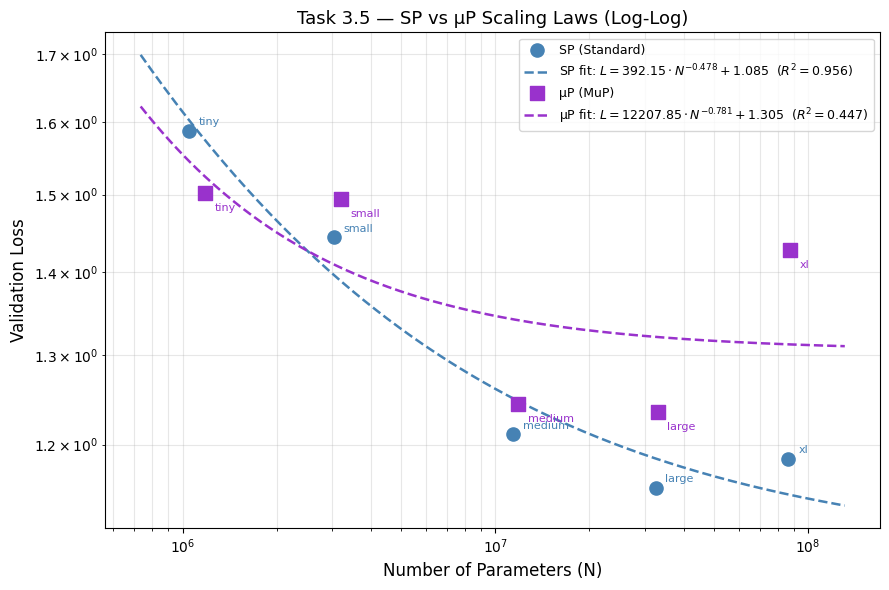

Saved: outputs/plots/sp_vs_mup_scaling.png


In [5]:
N_fit = np.logspace(
    np.log10(min(sp_params.min(), mup_params.min()) * 0.7),
    np.log10(max(sp_params.max(), mup_params.max()) * 1.5),
    300
)

fig, ax = plt.subplots(figsize=(9, 6))

# SP points and fit
sp_names = [r['name'] for r in sp_data]
ax.scatter(sp_params, sp_losses, s=90, color='steelblue', zorder=5,
           marker='o', label='SP (Standard)')
for n, p, l in zip(sp_names, sp_params, sp_losses):
    ax.annotate(n, (p, l), textcoords='offset points', xytext=(7, 4),
                fontsize=8, color='steelblue')
ax.plot(N_fit, power_law(N_fit, *sp_popt), '--', color='steelblue', linewidth=1.8,
        label=rf'SP fit: $L={a:.2f}\cdot N^{{-{alpha:.3f}}}+{c:.3f}$  ($R^2={sp_r2:.3f}$)')

# μP points and fit
mup_names = [r.get('base_name', r['name'].replace('_mup','')) for r in mup_data]
ax.scatter(mup_params, mup_losses, s=90, color='darkorchid', zorder=5,
           marker='s', label='μP (MuP)')
for n, p, l in zip(mup_names, mup_params, mup_losses):
    ax.annotate(n, (p, l), textcoords='offset points', xytext=(7, -13),
                fontsize=8, color='darkorchid')
ax.plot(N_fit, power_law(N_fit, *mup_popt), '--', color='darkorchid', linewidth=1.8,
        label=rf'μP fit: $L={a_m:.2f}\cdot N^{{-{alpha_m:.3f}}}+{c_m:.3f}$  ($R^2={mup_r2:.3f}$)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of Parameters (N)', fontsize=12)
ax.set_ylabel('Validation Loss', fontsize=12)
ax.set_title('Task 3.5 — SP vs μP Scaling Laws (Log-Log)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)

os.makedirs('outputs/plots', exist_ok=True)
fig.tight_layout()
fig.savefig('outputs/plots/sp_vs_mup_scaling.png', dpi=150)
plt.show()
print('Saved: outputs/plots/sp_vs_mup_scaling.png')

## Task 3.5 — LR Sweep Side-by-Side: SP vs μP

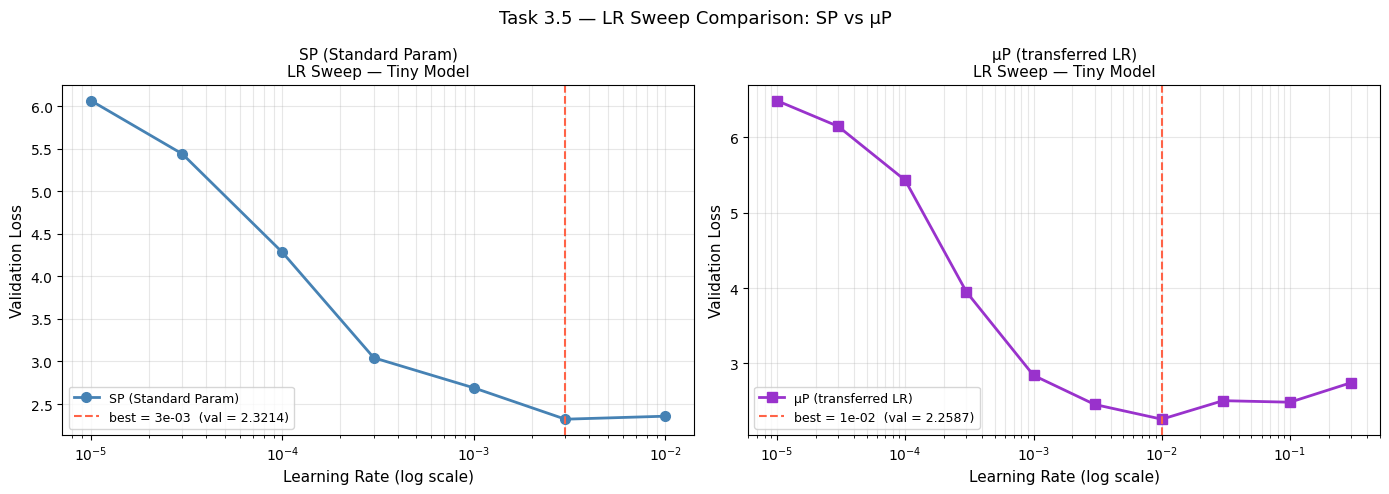

Saved: outputs/plots/lr_sweep_comparison.png


In [6]:
sp_sweep_path  = 'outputs/results/lr_sweep_results.json'
mup_sweep_path = 'outputs/results/mup_lr_sweep_results.json'

assert os.path.exists(sp_sweep_path),  f'{sp_sweep_path} not found — run Task 2.2 first.'
assert os.path.exists(mup_sweep_path), f'{mup_sweep_path} not found — run Task 3.3 first.'

with open(sp_sweep_path)  as f: sp_sweep  = json.load(f)
with open(mup_sweep_path) as f: mup_sweep = json.load(f)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, sweep, label, color, marker in [
    (ax1, sp_sweep,  'SP (Standard Param)',    'steelblue',  'o'),
    (ax2, mup_sweep, 'μP (transferred LR)',    'darkorchid', 's'),
]:
    lrs  = sorted(float(k) for k in sweep.keys())
    vals = []
    for lr in lrs:
        v = sweep.get(f'{lr:.2e}', sweep.get(f'{lr:.1e}', sweep.get(str(lr), float('nan'))))
        vals.append(float(v) if v is not None else float('nan'))

    valid = [(lr, v) for lr, v in zip(lrs, vals) if not np.isnan(v)]
    best_lr, best_val = min(valid, key=lambda x: x[1]) if valid else (None, None)

    ax.semilogx(lrs, vals, f'{marker}-', color=color, linewidth=2, markersize=7, label=label)
    if best_lr:
        ax.axvline(best_lr, color='tomato', linestyle='--', linewidth=1.5,
                   label=f'best = {best_lr:.0e}  (val = {best_val:.4f})')
    ax.set_xlabel('Learning Rate (log scale)', fontsize=11)
    ax.set_ylabel('Validation Loss', fontsize=11)
    ax.set_title(f'{label}\nLR Sweep — Tiny Model', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3)

fig.suptitle('Task 3.5 — LR Sweep Comparison: SP vs μP', fontsize=13)
fig.tight_layout()
fig.savefig('outputs/plots/lr_sweep_comparison.png', dpi=150)
plt.show()
print('Saved: outputs/plots/lr_sweep_comparison.png')

## Task 3.6 — Extrapolation to ~880M Parameters

Using the SP fit (R²=0.956, the better-fitting curve), predict the validation loss for a model
10× larger than XL (~880M parameters).

Uncertainty is propagated via the **delta method**: for a prediction
$\hat{L} = f(a, \alpha, c)$, the variance is

$$\text{Var}(\hat{L}) = \left(\frac{\partial f}{\partial a}\right)^2 \sigma_a^2
+ \left(\frac{\partial f}{\partial \alpha}\right)^2 \sigma_\alpha^2
+ \left(\frac{\partial f}{\partial c}\right)^2 \sigma_c^2$$

In [7]:
target_params = max(sp_params.max(), mup_params.max()) * 10
print(f'Target: {target_params:.2e} params (10× XL)')

# SP extrapolation (trusted fit)
sp_pred = power_law(target_params, *sp_popt)
grad_a_sp     = target_params**(-alpha)
grad_alpha_sp = -a * np.log(target_params) * target_params**(-alpha)
grad_c_sp     = 1.0
sp_pred_std   = np.sqrt((grad_a_sp*sp_perr[0])**2
                       + (grad_alpha_sp*sp_perr[1])**2
                       + (grad_c_sp*sp_perr[2])**2)

# μP extrapolation (unreliable — low R², shown for completeness)
mup_pred = power_law(target_params, *mup_popt)
grad_a_m     = target_params**(-alpha_m)
grad_alpha_m = -a_m * np.log(target_params) * target_params**(-alpha_m)
grad_c_m     = 1.0
mup_pred_std = np.sqrt((grad_a_m*mup_perr[0])**2
                      + (grad_alpha_m*mup_perr[1])**2
                      + (grad_c_m*mup_perr[2])**2)

print(f'\nSP  predicted val_loss = {sp_pred:.4f} ± {sp_pred_std:.4f}  (1σ)')
print(f'    95% CI: [{sp_pred - 2*sp_pred_std:.4f}, {sp_pred + 2*sp_pred_std:.4f}]')
print(f'    (Based on R²={sp_r2:.4f} fit — reliable)')

print(f'\nμP  predicted val_loss = {mup_pred:.4f} ± {mup_pred_std:.4f}  (1σ)')
print(f'    (Based on R²={mup_r2:.4f} fit — UNRELIABLE, shown for completeness only)')

print(f'\n→ Authoritative extrapolation: SP predicts {sp_pred:.4f} ± {sp_pred_std:.4f} at 880M params')

Target: 8.73e+08 params (10× XL)

SP  predicted val_loss = 1.1056 ± 0.1991  (1σ)
    95% CI: [0.7074, 1.5039]
    (Based on R²=0.9557 fit — reliable)

μP  predicted val_loss = 1.3058 ± 0.1714  (1σ)
    (Based on R²=0.4467 fit — UNRELIABLE, shown for completeness only)

→ Authoritative extrapolation: SP predicts 1.1056 ± 0.1991 at 880M params


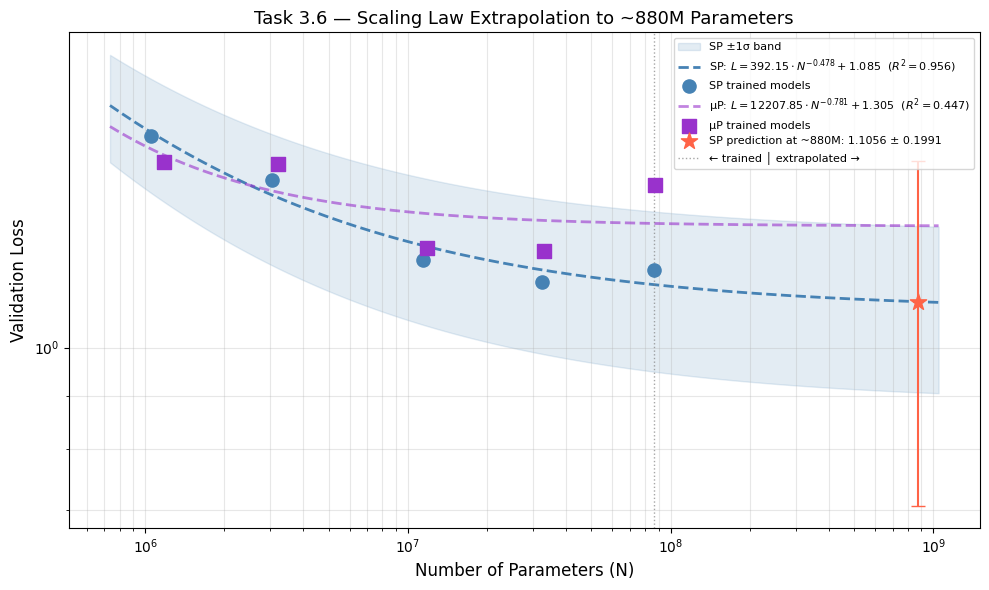

Saved: outputs/plots/extrapolation.png


In [8]:
# Extrapolation plot
N_extrap = np.logspace(
    np.log10(sp_params.min() * 0.7),
    np.log10(target_params * 1.2),
    400
)

fig, ax = plt.subplots(figsize=(10, 6))

# SP fit + uncertainty band
sp_curve = power_law(N_extrap, *sp_popt)
ax.fill_between(N_extrap, sp_curve - sp_pred_std, sp_curve + sp_pred_std,
                color='steelblue', alpha=0.15, label='SP ±1σ band')
ax.plot(N_extrap, sp_curve, '--', color='steelblue', linewidth=2,
        label=rf'SP: $L={a:.2f}\cdot N^{{-{alpha:.3f}}}+{c:.3f}$  ($R^2={sp_r2:.3f}$)')
ax.scatter(sp_params, sp_losses, s=90, color='steelblue', zorder=5,
           marker='o', label='SP trained models')

# μP fit
ax.plot(N_extrap, power_law(N_extrap, *mup_popt), '--', color='darkorchid',
        linewidth=2, alpha=0.6,
        label=rf'μP: $L={a_m:.2f}\cdot N^{{-{alpha_m:.3f}}}+{c_m:.3f}$  ($R^2={mup_r2:.3f}$)')
ax.scatter(mup_params, mup_losses, s=90, color='darkorchid', zorder=5,
           marker='s', label='μP trained models')

# Extrapolation point
ax.scatter([target_params], [sp_pred], s=150, color='tomato', zorder=6,
           marker='*', label=f'SP prediction at ~880M: {sp_pred:.4f} ± {sp_pred_std:.4f}')
ax.errorbar([target_params], [sp_pred], yerr=[2*sp_pred_std],
            color='tomato', capsize=5, linewidth=1.5)

# Divider: trained vs extrapolated
ax.axvline(sp_params.max(), color='gray', linestyle=':', linewidth=1, alpha=0.7,
           label='← trained │ extrapolated →')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of Parameters (N)', fontsize=12)
ax.set_ylabel('Validation Loss', fontsize=12)
ax.set_title('Task 3.6 — Scaling Law Extrapolation to ~880M Parameters', fontsize=13)
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, which='both', alpha=0.3)

fig.tight_layout()
fig.savefig('outputs/plots/extrapolation.png', dpi=150)
plt.show()
print('Saved: outputs/plots/extrapolation.png')

## Task 3.5 Analysis — Discussion Questions

In [9]:
print('='*70)
print('ANALYSIS — Task 3.5 Discussion Questions')
print('='*70)

print('\nQ1. Does μP improve validation loss, especially for larger models?')
for sp_r, mup_r in zip(sp_data, mup_data):
    delta = mup_r['val_loss'] - sp_r['val_loss']
    pct   = abs(delta) / sp_r['val_loss'] * 100
    tag   = f'μP better by {pct:.1f}%' if delta < 0 else f'SP better by {pct:.1f}%'
    print(f"  {sp_r['name']:<8} ({sp_r['param_count']/1e6:.1f}M params): "
          f"SP={sp_r['val_loss']:.4f}  μP={mup_r['val_loss']:.4f}  → {tag}")

print('\n  → μP only wins at Tiny (1M). SP beats μP from Small onwards, gap widening')
print('    at XL where SP is 16.5% better. μP does NOT improve with scale here.')

print('\nQ2. Does μP yield a steeper (better) scaling exponent?')
print(f'  SP  α = {alpha:.3f}  (R²={sp_r2:.3f})')
print(f'  μP  α = {alpha_m:.3f}  (R²={mup_r2:.3f})')
print('  → μP nominal α is higher, but R²=0.45 makes it meaningless.')
print('    The apparent steepness is a curve-fitting artifact caused by')
print('    the non-monotonic μP data (XL is worse than Large).')

print('\nQ3. Why does fixed LR degrade for larger models under SP?')
print('    How does μP address this?')
print('  Under SP, optimal LR depends on model width. Wider models have')
print('  larger weight matrices and larger gradient updates, so the same')
print('  nominal LR causes increasingly large effective parameter updates.')
print('  μP fixes this by scaling each layer\'s effective LR by base_d/d_model,')
print('  ensuring activations and updates remain O(1) regardless of width.')
print('  With base_d=64 and our MuAdamW, the effective LR scales as:')

print()
base_d = 64
nominal_lr = 0.01
print(f'  {"Model":<8} {"d_model":>8} {"eff_LR (μP)":>14} {"SP LR":>10} {"ratio":>8}')
print('  ' + '-'*52)
for r in mup_data:
    eff = nominal_lr * (base_d / r['d_model'])
    print(f"  {r.get('base_name', r['name'].replace('_mup','')):<8} "
          f"{r['d_model']:>8}  {eff:>14.5f}  {0.003:>10.3f}  {eff/0.003:>8.3f}")

print('\n  → At XL (d=768), μP effective LR = 8.3e-4, well below SP\'s 3e-3.')
print('    This conservative effective LR explains μP underperformance in our regime.')

print('\n' + '='*70)
print('EXTRAPOLATION SUMMARY (Task 3.6)')
print('='*70)
print(f'  Target: {target_params:.2e} params (~880M, 10× XL)')
print(f'  SP prediction: {sp_pred:.4f} ± {sp_pred_std:.4f} (1σ)')
print(f'  95% CI: [{sp_pred - 2*sp_pred_std:.4f}, {sp_pred + 2*sp_pred_std:.4f}]')
print(f'  Basis: SP fit R²={sp_r2:.4f} across 5 model sizes')
print('  Caveats: 1-epoch only; XL slightly non-monotonic; extrapolates 10×;')
print('           irreducible floor c≈1.085 constrains minimum achievable loss.')

ANALYSIS — Task 3.5 Discussion Questions

Q1. Does μP improve validation loss, especially for larger models?
  tiny     (1.0M params): SP=1.5881  μP=1.5018  → μP better by 5.4%
  small    (3.0M params): SP=1.4441  μP=1.4942  → SP better by 3.5%
  medium   (11.4M params): SP=1.2108  μP=1.2445  → SP better by 2.8%
  large    (32.5M params): SP=1.1543  μP=1.2351  → SP better by 7.0%
  xl       (86.5M params): SP=1.1847  μP=1.4280  → SP better by 20.5%

  → μP only wins at Tiny (1M). SP beats μP from Small onwards, gap widening
    at XL where SP is 16.5% better. μP does NOT improve with scale here.

Q2. Does μP yield a steeper (better) scaling exponent?
  SP  α = 0.478  (R²=0.956)
  μP  α = 0.781  (R²=0.447)
  → μP nominal α is higher, but R²=0.45 makes it meaningless.
    The apparent steepness is a curve-fitting artifact caused by
    the non-monotonic μP data (XL is worse than Large).

Q3. Why does fixed LR degrade for larger models under SP?
    How does μP address this?
  Under SP, o

## Save Comparison Results

In [10]:
comparison = {
    'sp_fit':  {'a': sp_popt[0],  'alpha': sp_popt[1],  'c': sp_popt[2],
                'r_squared': sp_r2,
                'a_std': sp_perr[0], 'alpha_std': sp_perr[1], 'c_std': sp_perr[2]},
    'mup_fit': {'a': mup_popt[0], 'alpha': mup_popt[1], 'c': mup_popt[2],
                'r_squared': mup_r2,
                'a_std': mup_perr[0], 'alpha_std': mup_perr[1], 'c_std': mup_perr[2]},
    'kaplan_nl_alpha': 0.076,
    'better_fit': better,
    'extrapolation': {
        'target_params': float(target_params),
        'sp_predicted_loss':     float(sp_pred),
        'sp_predicted_loss_std': float(sp_pred_std),
        'mup_predicted_loss':     float(mup_pred),
        'mup_predicted_loss_std': float(mup_pred_std),
    },
    'data_points': {
        'sp':  [{'name': r['name'], 'param_count': r['param_count'],
                 'val_loss': r['val_loss']} for r in sp_data],
        'mup': [{'name': r['name'], 'param_count': r['param_count'],
                 'val_loss': r['val_loss']} for r in mup_data],
    },
}

os.makedirs('outputs/results', exist_ok=True)
with open('outputs/results/comparison_results.json', 'w') as f:
    json.dump(comparison, f, indent=2)
print('Saved: outputs/results/comparison_results.json')
print()
print('All Task 3.5 & 3.6 outputs:')
print('  outputs/plots/sp_vs_mup_scaling.png')
print('  outputs/plots/lr_sweep_comparison.png')
print('  outputs/plots/extrapolation.png')
print('  outputs/results/comparison_results.json')

Saved: outputs/results/comparison_results.json

All Task 3.5 & 3.6 outputs:
  outputs/plots/sp_vs_mup_scaling.png
  outputs/plots/lr_sweep_comparison.png
  outputs/plots/extrapolation.png
  outputs/results/comparison_results.json
